In [3]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio

# =======================================================
# 1. BỘ XỬ LÝ MEGA OXFORD (1 file chứa nhiều Cell)
# =======================================================
def process_oxford_mega_mat(file_path):
    extracted_cycles = []
    try:
        print(f"Đang mở file Oxford: {os.path.basename(file_path)}...")
        mat = sio.loadmat(file_path)
        cell_keys = [k for k in mat.keys() if 'Cell' in k]
        
        for cell_key in cell_keys:
            cell_data = mat[cell_key]
            cycle_names = [n for n in cell_data.dtype.names if 'cyc' in n]
            
            for cyc in cycle_names:
                cyc_data = cell_data[cyc][0, 0]
                time = cyc_data['t'][0, 0].flatten()
                if len(time) == 0: continue
                
                voltage = cyc_data['v'][0, 0].flatten()
                current = cyc_data['i'][0, 0].flatten()
                temp = cyc_data['temp'][0, 0].flatten()
                c_rate = current / 0.74 # Oxford 0.74Ah
                
                extracted_cycles.append({
                    'Source': 'Oxford',
                    'File_Name': f"{os.path.basename(file_path)}_{cell_key}_{cyc}", 
                    'Cycle_Duration_sec': time[-1] - time[0],
                    'V_max': np.max(voltage), 'V_min': np.min(voltage), 'V_mean': np.mean(voltage),
                    'C_rate_max': np.max(c_rate), 'C_rate_min': np.min(c_rate), 'C_rate_mean': np.mean(c_rate),
                    'Temp_max': np.max(temp), 'Temp_mean': np.mean(temp),
                    'Target_Capacity_Ah': np.trapz(np.abs(current), time) / 3600.0
                })
        return extracted_cycles
    except Exception as e:
        print(f"Lỗi đọc Oxford: {e}")
        return []

# =======================================================
# 2. BỘ XỬ LÝ LGHG2
# =======================================================
def process_lghg2_mat(file_path):
    try:
        mat = sio.loadmat(file_path)
        meas = mat['meas']
        time, voltage, current = meas['Time'][0][0].flatten(), meas['Voltage'][0][0].flatten(), meas['Current'][0][0].flatten()
        temp = meas['Battery_Temp_degC'][0][0].flatten() if 'Battery_Temp_degC' in meas.dtype.names else meas['Temperature'][0][0].flatten()
        c_rate = current / 3.0 # LGHG2 3.0Ah
        
        return [{
            'Source': 'LGHG2',
            'File_Name': os.path.basename(file_path),
            'Cycle_Duration_sec': time[-1] - time[0],
            'V_max': np.max(voltage), 'V_min': np.min(voltage), 'V_mean': np.mean(voltage),
            'C_rate_max': np.max(c_rate), 'C_rate_min': np.min(c_rate), 'C_rate_mean': np.mean(c_rate),
            'Temp_max': np.max(temp), 'Temp_mean': np.mean(temp),
            'Target_Capacity_Ah': np.trapz(np.abs(current), time) / 3600.0
        }]
    except Exception: return []

# =======================================================
# 3. CHẠY GỘP 4 BỘ DỮ LIỆU
# =======================================================
print("BẮT ĐẦU CÀY CUỐC VÀ GỘP DỮ LIỆU...\n")
oxford_data = [item for f in glob.glob("Oxford_Data/*.mat") for item in process_oxford_mega_mat(f)]
lg_data = [item for f in glob.glob("LG_Data/*.mat") for item in process_lghg2_mat(f)]
df_mat = pd.DataFrame(oxford_data + lg_data)

# File CSV 1
df_csv1 = pd.read_csv('Battery_dataset.csv') if os.path.exists('Battery_dataset.csv') else pd.DataFrame()
if not df_csv1.empty:
    df_csv1 = df_csv1.rename(columns={'chV': 'V_max', 'disV': 'V_min', 'chT': 'Temp_max', 'disT': 'Temp_mean', 'BCt': 'Target_Capacity_Ah'})
    df_csv1['C_rate_mean'] = df_csv1['chI']
    df_csv1['Source'] = 'CSV_1'

# File CSV 2
df_csv2 = pd.read_csv('ev_battery_charging_data.csv') if os.path.exists('ev_battery_charging_data.csv') else pd.DataFrame()
if not df_csv2.empty:
    df_csv2 = df_csv2.rename(columns={'Voltage (V)': 'V_mean', 'Battery Temp (°C)': 'Temp_mean', 'Charging Duration (min)': 'Cycle_Duration_sec'})
    df_csv2['Cycle_Duration_sec'] *= 60
    df_csv2['C_rate_mean'] = df_csv2['Current (A)']
    df_csv2['Target_Capacity_Ah'] = 3.0 * (df_csv2['SOC (%)'] / 100)
    df_csv2['Source'] = 'CSV_2'

master_df = pd.concat([df_mat, df_csv1, df_csv2], axis=0, ignore_index=True).fillna(0)
master_df.to_csv('Master_Battery_Dataset.csv', index=False)
print(f"\n✅ Đã tạo thành công Master_Battery_Dataset.csv! Kích thước: {master_df.shape[0]} dòng.")

BẮT ĐẦU CÀY CUỐC VÀ GỘP DỮ LIỆU...

Đang mở file Oxford: Oxford_Battery_Degradation_Dataset_1.mat...
Lỗi đọc Oxford: no field of name t

✅ Đã tạo thành công Master_Battery_Dataset.csv! Kích thước: 1680 dòng.


Cell 1: Nạp thư viện và Gom toàn bộ dữ liệu thành "Master Dataset"

In [4]:
import sys
!{sys.executable} -m pip install seaborn matplotlib pandas scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Admin\AppData\Local\Temp\ipykernel_8428\3085633406.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_model.feature_importances_, y=X.columns, palette='magma')


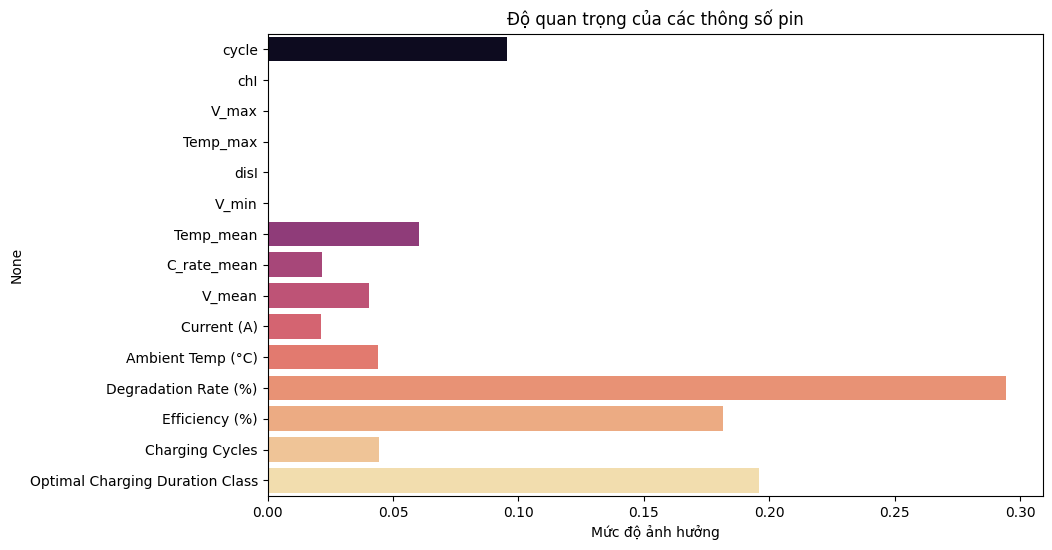

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Nạp dữ liệu
master_df = pd.read_csv('Master_Battery_Dataset.csv').dropna(subset=['Target_Capacity_Ah'])

# Xử lý đặc trưng
cols_to_drop = ['Target_Capacity_Ah', 'SOH', 'SOC (%)', 'RUL', 'battery_id', 'Source', 'File_Name', 'Cycle_Duration_sec']
X_raw = master_df.drop(columns=[col for col in cols_to_drop if col in master_df.columns])
X = X_raw.select_dtypes(include=['number']).fillna(0)
y = master_df['Target_Capacity_Ah']

# Lấy mẫu nếu quá lớn
if len(X) > 50000:
    sample_idx = X.sample(n=50000, random_state=42).index
    X, y = X.loc[sample_idx], y.loc[sample_idx]

# Huấn luyện
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_model.feature_importances_, y=X.columns, palette='magma')
plt.title('Độ quan trọng của các thông số pin')
plt.xlabel('Mức độ ảnh hưởng')
plt.show()

Cell 2: Tiền xử lý, Hồi quy tuyến tính & Random Forest

In [6]:
import sys
!{sys.executable} -m pip install torch


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Chuyển dữ liệu sang Tensor cho PyTorch
# Lưu ý: X_train_scaled và y_train phải được định nghĩa từ bước trước
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# 2. Xây dựng cấu trúc mạng Neural Network 
class BatteryDNN(nn.Module):
    def __init__(self, input_dim):
        super(BatteryDNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Chống học vẹt (Overfitting)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Đầu ra dự đoán Capacity
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_scaled.shape[1]
dnn_model = BatteryDNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

# 3. Vòng lặp Huấn luyện (Training)
epochs = 50
print("Đang huấn luyện mạng nơ-ron sâu (Deep Learning)...")
for epoch in range(epochs):
    dnn_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = dnn_model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

# 4. Đánh giá mô hình
dnn_model.eval()
with torch.no_grad():
    y_pred_dnn = dnn_model(X_test_t)
    # Chuyển tensor về numpy để tính R2 score
    r2_dnn = r2_score(y_test_t.numpy(), y_pred_dnn.numpy())
    print(f"\n--- PyTorch DNN ---")
    print(f"R2 Score trên tập Test: {r2_dnn:.4f}")

Đang huấn luyện mạng nơ-ron sâu (Deep Learning)...
Epoch 10/50 | Loss: 0.1846
Epoch 20/50 | Loss: 0.1634
Epoch 30/50 | Loss: 0.1796
Epoch 40/50 | Loss: 0.1248
Epoch 50/50 | Loss: 0.1331

--- PyTorch DNN ---
R2 Score trên tập Test: 0.6984


Cell 3: Mạng Nơ-ron Học Sâu (PyTorch DNN)

In [8]:
import joblib
import torch

# 1. Lưu cấu trúc và trọng số của Random Forest
joblib.dump(rf_model, 'master_battery_rf_model.pkl')

# 2. LƯU Ý QUAN TRỌNG: Phải lưu luôn cả bộ Chuẩn hóa (Scaler)
joblib.dump(scaler, 'master_battery_scaler.pkl')

# 3. Lưu trọng số của Mạng Nơ-ron PyTorch
torch.save(dnn_model.state_dict(), 'master_battery_dnn.pth')

print("✅ Đã lưu trữ thành công toàn bộ mô hình và bộ chuẩn hóa để dùng cho thực tế!")

✅ Đã lưu trữ thành công toàn bộ mô hình và bộ chuẩn hóa để dùng cho thực tế!


In [9]:
import joblib
# Lưu tên cột thành một file
joblib.dump(list(X_train.columns), 'column_names.pkl')

['column_names.pkl']

Cell 4: Đóng gói và Lưu Mô hình